In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt

# подключаем функции fft, fftfreq
from scipy.fft import fft, fftfreq


In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значения циклической частоты
# для данного значения волнового вектора
def Omega(k):
    return k + 0.5 * k**2


In [3]:
# Ячейка № 3

# вычисление значений
# действительной и мнимой частей
# начального возмущения
# в узлах выбранной
# координатной сетки
# в момент времени t = 0

# задание пространственной
# координатной сетки
Nx = 2**10
X_min = -10 * np.pi
X_max = 60 * np.pi
x = np.linspace(X_min, X_max, Nx)

# задание параметров
# начального возмущения

# задание амплитуды
# начального возмущения
A = 1
# задание волнового вектора
# начального возмущения
k0 = 0.5

# вычисление значений
# комплексной функции,
# описывающей начальное возмущение

z = A * np.exp(1j * k0 * x[:]) * np.exp(-((x[:] / 10) ** 2))


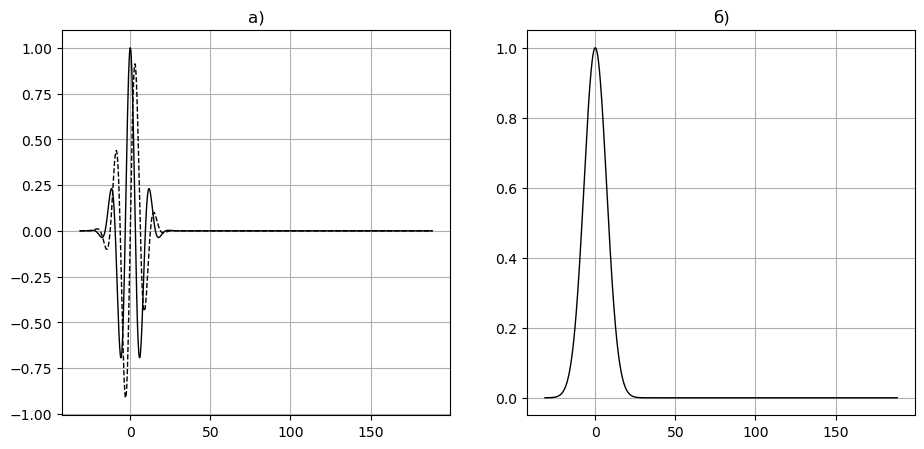

In [4]:
# Ячейка № 4

# визуализация действительной,
# мнимой составляющих и огибающей
# начального возмущения

fig = plt.figure(figsize=(11, 5))

# визуализация действительной и мнимой
# составляющих начального возмущения
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x, np.real(z), "-k", lw=1)
ax1.plot(x, np.imag(z), "k--", lw=1)
ax1.grid(True)
plt.title("a)")

# визуализация огибающей
# начального возмущения
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x, np.abs(z), "-k", lw=1)
ax2.grid(True)
plt.title("б)")

plt.show()

In [5]:
# Ячейка № 5

# вычисление и визуализация спектра
# спектра волнового пакета
# и его огибающих в выбранные
# моменты времени

# вычисление быстрого преобразования Фурье
# по переменной х волнового пакета в момент
# времени t = 0
s = fft(z)

# нормировка спектра на число отсчетов
# исходной последовательности
s = s / Nx

# вычисляем базовую циклическую частоту
# дикретного преобразования Фурье
k = 2 * np.pi / (X_max - X_min)


# задание функции, возвращающей
# значения волнового пакета
# в выбранные моменты времени
# в соответствие с (9.67)
def WavePacket(s, x, t, k, Nx):
    psi = np.zeros(Nx) + 1j * np.zeros(Nx)
    for j in range(Nx):
        su = 0
        for n in range(Nx):
            su = su + s[n] * np.exp(1j * (k * n * (x[j] - X_min) - Omega(k * n) * t))
        psi[j] = su

    return psi


# визуализация спектра волнового пакета
# в выбранные моменты времени
dx = x[1] - x[0]

# вычисление частот спектральных гармоник
Freq = fftfreq(Nx, dx)

# вычисление значения
# наибольшего номера
# информативной спектральной гармоники
N2 = round((Nx - 1) / 2) - 1

# вычисление значений
# частот информативных гармоник
Freq_R = np.zeros(N2)
for i in range(N2):
    Freq_R[i] = Freq[i + 1]

    # выделение информативной части
    # спектра i-ой моды
    # нормальных колебаний
    s_R1 = np.zeros(N2)
    for j in range(N2):
        s_R1[j] = np.abs(2 * s[j + 1])


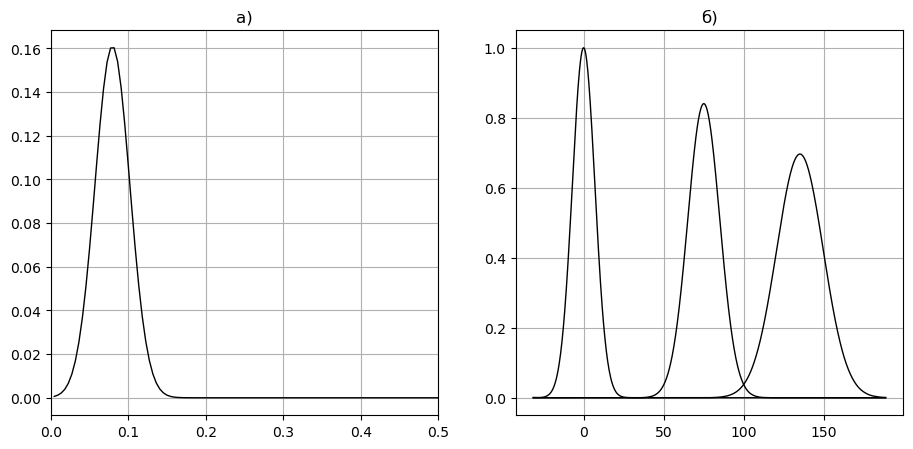

In [ ]:
# Ячейка № 6

# визуализация спектра волнового пакета
# и огибающих волновых пакетов в выбранные
# моменты времени

fig = plt.figure(figsize=(11, 5))

# визуализация спектра волнового пакета
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(Freq_R, s_R1, "-k", lw=1)
ax1.set_xlim([0, 0.5])
ax1.grid(True)
plt.title("a)")

# вычисление значений волнового пакета
# в узлах выбранной координатной сетки
# в выбранные моменты времени
t1 = 0
Psi1 = WavePacket(s, x, t1, k, Nx)

t2 = 50
Psi2 = WavePacket(s, x, t2, k, Nx)

t3 = 90
Psi3 = WavePacket(s, x, t3, k, Nx)

# визуализация огибающих волнового пакета,
# выбранные моменты времени
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x, np.abs(Psi1), "-k", lw=1)
ax2.plot(x, np.abs(Psi2), "-k", lw=1)
ax2.plot(x, np.abs(Psi3), "-k", lw=1)
ax2.grid(True)
plt.title("б)")

plt.show()